# CLIP Multimodal Embeddings — Hateful Memes

**Research question:** Do CLIP multimodal (image+text) representations make the Hateful Memes classification problem geometrically simpler than unimodal representations?

## Workflow
1. Dataset analysis (size, class balance)
2. Fine-tune CLIP on the train split for binary classification
3. Extract embeddings from the **validation split** using the fine-tuned backbone
4. Build 5 representations: `image_only`, `text_only`, `concat`, `mean`, `absolute_difference`
5. Save to `.npz` — meta-feature extraction is conducted separately

> **Data source:** Local Kaggle download at `data/hateful_memes_kaggle/`  
> ([parthplc/facebook-hateful-meme-dataset](https://www.kaggle.com/datasets/parthplc/facebook-hateful-meme-dataset))

## 1. Setup

In [29]:
import io
import json
import logging
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset as HFDataset, Image as HFImage
from PIL import Image
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from torch.utils.data import DataLoader, Dataset
from transformers import CLIPModel, CLIPProcessor, ViltModel, ViltProcessor

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from features_extraction.device import DeviceManager

# ── Constants ────────────────────────────────────────────────────────────────
MODEL_ID          = "openai/clip-vit-base-patch32"
VILT_MODEL_ID     = "dandelin/vilt-b32-finetuned-vqa"

DATA_DIR          = REPO_ROOT / "data" / "hateful_memes_kaggle"
OUTPUT_DIR        = REPO_ROOT / "data" / "embeddings"
CKPT_DIR          = REPO_ROOT / "data" / "pretrained_models" / "clip_hateful_memes"
CKPT_DIR_VILT     = REPO_ROOT / "data" / "pretrained_models" / "vilt_hateful_memes"

BATCH_SIZE        = 32
EPOCHS            = 5
LR_HEAD           = 1e-3
LR_BACKBONE       = 2e-5
WEIGHT_DECAY      = 0.01
WARMUP_FRAC       = 0.06
SEED              = 42
MAX_TEXT_LEN      = 77   # CLIP context length
MAX_TEXT_LEN_VILT = 40   # architectural hard limit: ViltConfig.max_position_embeddings=40

for d in (OUTPUT_DIR, CKPT_DIR, CKPT_DIR_VILT):
    d.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = DeviceManager.resolve("auto")
print(f"Device: {DEVICE}")

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
    level=logging.WARNING,
)
log = logging.getLogger(__name__)

Device: mps


## 2. Dataset Analysis

In [30]:
# ── Load from local Kaggle files ─────────────────────────────────────────────
IMG_ROOT  = DATA_DIR / "data"
IMG_COL   = "img"
TEXT_COL  = "text"
LABEL_COL = "label"

def load_split(jsonl_path: Path, img_root: Path):
    rows = [json.loads(line) for line in open(jsonl_path)]
    return HFDataset.from_dict({
        "img":   [str(img_root / r["img"]) for r in rows],
        "text":  [r["text"] for r in rows],
        "label": [int(r["label"]) for r in rows],
    }).cast_column("img", HFImage())

print("Loading Hateful Memes from local files ...")
train_ds = load_split(IMG_ROOT / "train.jsonl", IMG_ROOT)
val_ds   = load_split(IMG_ROOT / "dev.jsonl",   IMG_ROOT)
# test.jsonl has no labels — not used in this experiment

print(f"\nSplit sizes  : train={len(train_ds)}, val={len(val_ds)}")
print(f"Column names : {train_ds.column_names}")

sample = train_ds[0]
print(f"\nimg type     : {type(sample[IMG_COL]).__name__}")
print(f"text sample  : {str(sample[TEXT_COL])[:80]}")
print(f"label        : {sample[LABEL_COL]}")

Loading Hateful Memes from local files ...

Split sizes  : train=8500, val=500
Column names : ['img', 'text', 'label']

img type     : PngImageFile
text sample  : its their character not their color that matters
label        : 0


In [54]:
# ── Stratified subsample (balanced classes) ───────────────────────────────────
N_PER_CLASS = 500  # total = N_PER_CLASS * n_classes

rng = random.Random(SEED)
labels_all = np.array(train_ds[LABEL_COL])

indices = []
for cls in np.unique(labels_all):
    cls_indices = np.where(labels_all == cls)[0].tolist()
    indices.extend(rng.sample(cls_indices, N_PER_CLASS))

train_ds = train_ds.select(indices)

print(f"Using {len(train_ds)} training samples (val unchanged: {len(val_ds)})")
labels_sub = np.array(train_ds[LABEL_COL])
unique, counts = np.unique(labels_sub, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names[int(u)]}: {c} ({100*c/len(labels_sub):.1f}%)")


Using 1000 training samples (val unchanged: 500)
  not hateful: 500 (50.0%)
  hateful: 500 (50.0%)


     split       label  count       pct
     train not hateful   5450 64.117647
     train     hateful   3050 35.882353
validation not hateful    250 50.000000
validation     hateful    250 50.000000


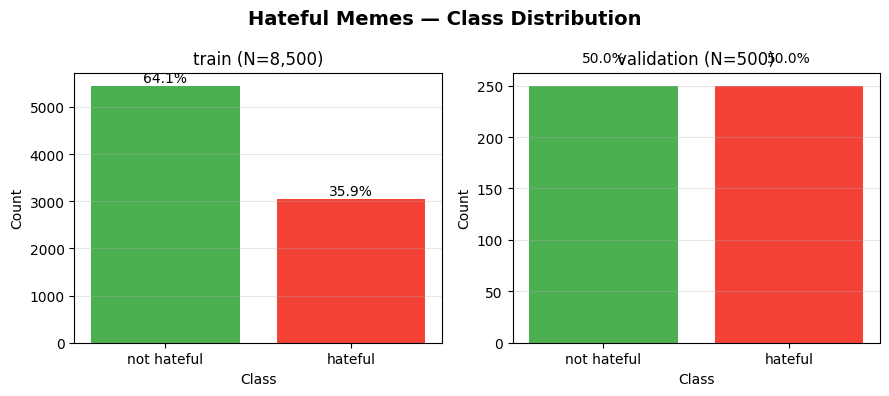

In [31]:
# ── Class distribution ────────────────────────────────────────────────────────
label_names = {0: "not hateful", 1: "hateful"}
splits = [("train", train_ds), ("validation", val_ds)]

split_info = []
for split_name, split_data in splits:
    labels = np.array(split_data[LABEL_COL])
    unique, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    for u, c in zip(unique, counts):
        split_info.append({
            "split": split_name, "label": label_names.get(int(u), str(u)),
            "count": int(c), "pct": 100 * c / total
        })

dist_df = pd.DataFrame(split_info)
print(dist_df.to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (split_name, _) in zip(axes, splits):
    sub = dist_df[dist_df["split"] == split_name]
    bars = ax.bar(sub["label"], sub["count"], color=["#4CAF50", "#F44336"])
    ax.set_title(f"{split_name} (N={sub['count'].sum():,})", fontsize=12)
    ax.set_xlabel("Class"); ax.set_ylabel("Count")
    for bar, pct in zip(bars, sub["pct"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Hateful Memes — Class Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Display a few examples inline ────────────────────────────────────────────
def show_samples(dataset, n=4, title="Samples"):
    """Render N sample memes with their label and text."""
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        item = dataset[idx]
        img = coerce_to_pil(item[IMG_COL]) if IMG_COL in item else Image.new("RGB", (100, 100))
        label = label_names.get(int(item[LABEL_COL]), str(item[LABEL_COL]))
        text  = str(item[TEXT_COL])[:60]
        ax.imshow(img)
        ax.set_title(f"{label}\n\"{text}...\"", fontsize=8, wrap=True)
        ax.axis("off")
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# NOTE: show_samples relies on coerce_to_pil defined in Section 3.
# Run the helper cells first, then re-run this cell if needed.

## 3. CLIP Fine-Tuning

We add a binary classification head on top of `concat(image_embed, text_embed)` and fine-tune the full CLIP backbone with a lower learning rate for the backbone vs the head.

**Architecture:** `CLIPModel` → L2-normalize image & text embeddings → concat `[N, 1024]` → `Linear(1024, 2)`

After training, only the CLIP backbone is used for embedding extraction — the head is discarded.

In [ ]:
# ── Helper functions (adapted from scripts/extract_snli_ve_clip.py) ───────────

def l2_normalize(x: torch.Tensor) -> torch.Tensor:
    return x / x.norm(dim=-1, keepdim=True).clamp_min(1e-12)


def coerce_to_pil(img_field) -> Image.Image:
    """Convert any image representation to a PIL RGB Image."""
    if isinstance(img_field, Image.Image):
        img = img_field
    elif isinstance(img_field, dict) and "bytes" in img_field:
        img = Image.open(io.BytesIO(img_field["bytes"]))
    elif isinstance(img_field, dict) and "path" in img_field:
        img = Image.open(img_field["path"])
    elif isinstance(img_field, bytes):
        img = Image.open(io.BytesIO(img_field))
    elif isinstance(img_field, str):
        img = Image.open(img_field)
    else:
        raise TypeError(
            f"Unexpected image field type: {type(img_field).__name__}. "
            f"Content: {str(img_field)[:100]}"
        )
    return img.convert("RGB") if img.mode != "RGB" else img

In [ ]:
class CLIPClassifier(nn.Module):
    """CLIP backbone + binary classification head on concat(image_emb, text_emb)."""

    def __init__(self, model_id: str):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_id)
        embed_dim = self.clip.config.projection_dim  # 512 for ViT-B/32
        self.head = nn.Linear(embed_dim * 2, 2)

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        outputs = self.clip(
            input_ids=input_ids,
            pixel_values=pixel_values,
            attention_mask=attention_mask,
            return_dict=True,
        )
        img_emb = l2_normalize(outputs.image_embeds)
        txt_emb = l2_normalize(outputs.text_embeds)
        z = torch.cat([img_emb, txt_emb], dim=1)
        return self.head(z)

In [ ]:
# ── Dataset and DataLoader ────────────────────────────────────────────────────

class HatefulMemesDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            "image": coerce_to_pil(item[IMG_COL]),
            "text":  str(item[TEXT_COL]),
            "label": int(item[LABEL_COL]),
        }


def make_collate_fn(processor: CLIPProcessor, max_length: int):
    def collate(batch):
        images = [b["image"] for b in batch]
        texts  = [b["text"]  for b in batch]
        labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
        enc = processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        enc["labels"] = labels
        return enc
    return collate

In [ ]:
# ── Class weights (handle imbalance) ─────────────────────────────────────────

train_labels = np.array(train_ds[LABEL_COL])
_, class_counts = np.unique(train_labels, return_counts=True)
class_weights = torch.tensor(
    len(train_labels) / (len(class_counts) * class_counts),
    dtype=torch.float32,
)
print(f"Class counts : {dict(enumerate(class_counts.tolist()))}")
print(f"Class weights: {dict(enumerate(class_weights.tolist()))}")

In [ ]:
# ── Training setup ────────────────────────────────────────────────────────────

CKPT_FILE = CKPT_DIR / "best_model.pt"
SKIP_TRAINING = CKPT_FILE.exists()

if SKIP_TRAINING:
    print(f"Checkpoint found at {CKPT_FILE} — skipping fine-tuning.")
    print("Delete the file to re-train from scratch.")
else:
    print("No checkpoint found — starting fine-tuning.")

    processor = CLIPProcessor.from_pretrained(MODEL_ID)
    model     = CLIPClassifier(MODEL_ID).to(DEVICE)

    collate_fn = make_collate_fn(processor, MAX_TEXT_LEN)
    train_loader = DataLoader(
        HatefulMemesDataset(train_ds), batch_size=BATCH_SIZE,
        shuffle=True, collate_fn=collate_fn, num_workers=0,
    )
    val_loader = DataLoader(
        HatefulMemesDataset(val_ds), batch_size=BATCH_SIZE,
        shuffle=False, collate_fn=collate_fn, num_workers=0,
    )

    # Differential learning rates: lower LR for pre-trained backbone
    optimizer = torch.optim.AdamW(
        [
            {"params": model.clip.parameters(), "lr": LR_BACKBONE},
            {"params": model.head.parameters(), "lr": LR_HEAD},
        ],
        weight_decay=WEIGHT_DECAY,
    )

    total_steps  = EPOCHS * len(train_loader)
    warmup_steps = int(WARMUP_FRAC * total_steps)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 1.0 - progress)

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    loss_fn   = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

    print(f"\nModel parameters : {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"Train batches    : {len(train_loader)} | Val batches: {len(val_loader)}")
    print(f"Total steps      : {total_steps} | Warmup: {warmup_steps}")

In [ ]:
# ── Training loop ────────────────────────────────────────────────────────────

if not SKIP_TRAINING:
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_val_f1 = -1.0

    for epoch in range(EPOCHS):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        running_loss, n_correct, n_total = 0.0, 0, 0

        for batch in train_loader:
            optimizer.zero_grad()
            pixel_values   = batch["pixel_values"].to(DEVICE)
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)

            logits = model(pixel_values, input_ids, attention_mask)
            loss   = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * labels.size(0)
            n_correct    += (logits.argmax(dim=1) == labels).sum().item()
            n_total      += labels.size(0)

        train_loss = running_loss / n_total
        train_acc  = n_correct / n_total

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        val_running_loss, val_preds_all, val_labels_all = 0.0, [], []

        with torch.no_grad():
            for batch in val_loader:
                pixel_values   = batch["pixel_values"].to(DEVICE)
                input_ids      = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels         = batch["labels"].to(DEVICE)

                logits = model(pixel_values, input_ids, attention_mask)
                val_running_loss += loss_fn(logits, labels).item() * labels.size(0)
                val_preds_all.extend(logits.argmax(dim=1).cpu().numpy())
                val_labels_all.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(val_ds)
        val_acc  = accuracy_score(val_labels_all, val_preds_all)
        val_f1   = f1_score(val_labels_all, val_preds_all, average="macro", zero_division=0)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_f1={val_f1:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), CKPT_FILE)
            print(f"  ✓  Best model saved  (val_f1={val_f1:.4f})")

    # Save training history for later reference
    with open(CKPT_DIR / "history.json", "w") as f:
        json.dump(history, f, indent=2)

    print(f"\nFine-tuning complete. Best val F1: {best_val_f1:.4f}")
    print(f"Checkpoint: {CKPT_FILE}")

In [ ]:
# ── Training curves ──────────────────────────────────────────────────────────

history_path = CKPT_DIR / "history.json"
if history_path.exists():
    with open(history_path) as f:
        history = json.load(f)

    epochs_x = list(range(1, len(history["train_loss"]) + 1))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs_x, history["train_loss"], "o-", label="train")
    axes[0].plot(epochs_x, history["val_loss"],   "s--", label="val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_x, history["train_acc"], "o-", label="train")
    axes[1].plot(epochs_x, history["val_acc"],   "s--", label="val")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs_x, history["val_f1"], "s--", color="C2", label="val macro-F1")
    axes[2].set_title("Val Macro-F1"); axes[2].set_xlabel("Epoch")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    fig.suptitle("CLIP Fine-Tuning — Training Curves", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No training history found. Run the training loop first.")

## 4b. ViLT Fine-Tuning

Unlike CLIP's dual encoder, **ViLT** processes image patches and text tokens together in a single joint transformer. There are no separate image/text embeddings — the model produces one pooled CLS representation per sample (`outputs.pooler_output [N, 768]`).

**Architecture:** `ViltModel` → `pooler_output [N, 768]` → `Linear(768, 2)`

In [55]:
class ViLTClassifier(nn.Module):
    """ViLT backbone + binary classification head on pooler_output."""

    def __init__(self, model_id: str):
        super().__init__()
        self.vilt = ViltModel.from_pretrained(model_id)
        self.head = nn.Linear(self.vilt.config.hidden_size, 2)  # 768 → 2

    def forward(self, pixel_values, input_ids, attention_mask, token_type_ids=None):
        outputs = self.vilt(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            pixel_values=pixel_values,
            return_dict=True,
        )
        return self.head(outputs.pooler_output)  # [N, 768] → [N, 2]

In [60]:
class ViLTDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            "image": coerce_to_pil(item[IMG_COL]),
            "text":  str(item[TEXT_COL]),
            "label": int(item[LABEL_COL]),
        }


def make_vilt_collate_fn(processor: ViltProcessor, max_length: int):
    def collate(batch):
        enc = processor(
            text=[b["text"] for b in batch],
            images=[b["image"] for b in batch],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        enc["labels"] = torch.tensor([b["label"] for b in batch], dtype=torch.long)
        return enc
    return collate

In [61]:
CKPT_FILE_VILT = CKPT_DIR_VILT / "best_model.pt"
SKIP_TRAINING_VILT = CKPT_FILE_VILT.exists()

if SKIP_TRAINING_VILT:
    print(f"ViLT checkpoint found at {CKPT_FILE_VILT} — skipping fine-tuning.")
else:
    print("No ViLT checkpoint found — starting fine-tuning.")

    vilt_processor_train = ViltProcessor.from_pretrained(VILT_MODEL_ID)
    vilt_model           = ViLTClassifier(VILT_MODEL_ID).to(DEVICE)

    # Freeze backbone — only train the classification head
    for param in vilt_model.vilt.parameters():
        param.requires_grad = False

    trainable = sum(p.numel() for p in vilt_model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in vilt_model.parameters())
    print(f"Trainable: {trainable:,} / {total:,} params ({100*trainable/total:.2f}%)")

    vilt_collate = make_vilt_collate_fn(vilt_processor_train, MAX_TEXT_LEN_VILT)
    vilt_train_loader = DataLoader(
        ViLTDataset(train_ds), batch_size=BATCH_SIZE,
        shuffle=True, collate_fn=vilt_collate, num_workers=0,
    )
    vilt_val_loader = DataLoader(
        ViLTDataset(val_ds), batch_size=BATCH_SIZE,
        shuffle=False, collate_fn=vilt_collate, num_workers=0,
    )

    # Only pass head parameters to optimizer
    vilt_optimizer = torch.optim.AdamW(
        vilt_model.head.parameters(),
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY,
    )

    vilt_total_steps  = EPOCHS * len(vilt_train_loader)
    vilt_warmup_steps = int(WARMUP_FRAC * vilt_total_steps)

    def vilt_lr_lambda(step):
        if step < vilt_warmup_steps:
            return step / max(1, vilt_warmup_steps)
        progress = (step - vilt_warmup_steps) / max(1, vilt_total_steps - vilt_warmup_steps)
        return max(0.0, 1.0 - progress)

    vilt_scheduler = torch.optim.lr_scheduler.LambdaLR(vilt_optimizer, vilt_lr_lambda)
    vilt_loss_fn   = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

    print(f"\nTrain batches : {len(vilt_train_loader)} | Val batches: {len(vilt_val_loader)}")
    print(f"Total steps   : {vilt_total_steps} | Warmup: {vilt_warmup_steps}")


No ViLT checkpoint found — starting fine-tuning.


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] ViltModel LOAD REPORT from: dandelin/vilt-b32-finetuned-vqa
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.{0, 1, 3}.bias   | UNEXPECTED |  | 
classifier.{0, 1, 3}.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable: 1,538 / 111,596,546 params (0.00%)

Train batches : 32 | Val batches: 16
Total steps   : 160 | Warmup: 9


In [58]:
# ── Memory cleanup ────────────────────────────────────────────────────────────
import gc

# Delete models and large tensors no longer needed
for var in ["model", "clf_model", "vilt_model", "vilt_clf_inf",
            "vilt_processor_train", "vilt_processor_inf",
            "processor", "processor_inf"]:
    if var in dir():
        del globals()[var]

gc.collect()

if DEVICE == "mps":
    torch.mps.empty_cache()
elif DEVICE == "cuda":
    torch.cuda.empty_cache()

print("Memory cleared.")


Memory cleared.


In [ ]:
if not SKIP_TRAINING_VILT:
    vilt_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    vilt_best_f1 = -1.0

    for epoch in range(EPOCHS):
        # ── Train ────────────────────────────────────────────────────────────
        vilt_model.train()
        running_loss, n_correct, n_total = 0.0, 0, 0

        for batch in vilt_train_loader:
            vilt_optimizer.zero_grad()
            pixel_values   = batch["pixel_values"].to(DEVICE)
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            logits = vilt_model(pixel_values, input_ids, attention_mask, token_type_ids)
            loss   = vilt_loss_fn(logits, labels)
            loss.backward()
            vilt_optimizer.step()
            vilt_scheduler.step()

            running_loss += loss.item() * labels.size(0)
            n_correct    += (logits.argmax(dim=1) == labels).sum().item()
            n_total      += labels.size(0)

        train_loss = running_loss / n_total
        train_acc  = n_correct / n_total

        # ── Validate ─────────────────────────────────────────────────────────
        vilt_model.eval()
        val_running_loss, val_preds_all, val_labels_all = 0.0, [], []

        with torch.no_grad():
            for batch in vilt_val_loader:
                pixel_values   = batch["pixel_values"].to(DEVICE)
                input_ids      = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                token_type_ids = batch.get("token_type_ids")
                if token_type_ids is not None:
                    token_type_ids = token_type_ids.to(DEVICE)
                labels = batch["labels"].to(DEVICE)

                logits = vilt_model(pixel_values, input_ids, attention_mask, token_type_ids)
                val_running_loss += vilt_loss_fn(logits, labels).item() * labels.size(0)
                val_preds_all.extend(logits.argmax(dim=1).cpu().numpy())
                val_labels_all.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(val_ds)
        val_acc  = accuracy_score(val_labels_all, val_preds_all)
        val_f1   = f1_score(val_labels_all, val_preds_all, average="macro", zero_division=0)

        vilt_history["train_loss"].append(train_loss)
        vilt_history["train_acc"].append(train_acc)
        vilt_history["val_loss"].append(val_loss)
        vilt_history["val_acc"].append(val_acc)
        vilt_history["val_f1"].append(val_f1)

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_f1={val_f1:.4f}"
        )

        if val_f1 > vilt_best_f1:
            vilt_best_f1 = val_f1
            torch.save(vilt_model.state_dict(), CKPT_FILE_VILT)
            print(f"  ✓  Best ViLT model saved  (val_f1={val_f1:.4f})")

    with open(CKPT_DIR_VILT / "history.json", "w") as f:
        json.dump(vilt_history, f, indent=2)

    print(f"\nViLT fine-tuning complete. Best val F1: {vilt_best_f1:.4f}")

In [ ]:
vilt_history_path = CKPT_DIR_VILT / "history.json"
if vilt_history_path.exists():
    with open(vilt_history_path) as f:
        vilt_history = json.load(f)

    epochs_x = list(range(1, len(vilt_history["train_loss"]) + 1))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs_x, vilt_history["train_loss"], "o-", label="train")
    axes[0].plot(epochs_x, vilt_history["val_loss"],   "s--", label="val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_x, vilt_history["train_acc"], "o-", label="train")
    axes[1].plot(epochs_x, vilt_history["val_acc"],   "s--", label="val")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs_x, vilt_history["val_f1"], "s--", color="C2", label="val macro-F1")
    axes[2].set_title("Val Macro-F1"); axes[2].set_xlabel("Epoch")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    fig.suptitle("ViLT Fine-Tuning — Training Curves", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No ViLT training history found. Run the training loop first.")

## 4c. ViLT Embedding Extraction (Validation Split)

Load the best ViLT checkpoint and extract `pooler_output` embeddings from the validation split. Since ViLT has no separate image/text towers, this yields a single joint representation per sample.

In [ ]:
def extract_vilt_embeddings(
    vilt_clf: ViLTClassifier,
    processor: ViltProcessor,
    dataset,
    device: str,
    batch_size: int,
    img_col: str = "img",
    text_col: str = "text",
    label_col: str = "label",
):
    """Extract L2-normalised pooler_output from fine-tuned ViLT backbone.

    Returns
    -------
    embeds : np.ndarray  [N, 768]
    labels : np.ndarray  [N]
    """
    chunks, label_chunks = [], []
    n = len(dataset)
    n_batches = (n + batch_size - 1) // batch_size

    vilt_clf.eval()
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end  = min(start + batch_size, n)
            rows = dataset[start:end]

            images, texts, labels = [], [], []
            for img_field, text, label in zip(rows[img_col], rows[text_col], rows[label_col]):
                try:
                    images.append(coerce_to_pil(img_field))
                    texts.append(str(text))
                    labels.append(int(label))
                except Exception as exc:
                    log.warning(f"Skipping invalid sample: {exc}")

            if not images:
                continue

            inputs = processor(
                text=texts, images=images,
                return_tensors="pt", padding=True,
                truncation=True, max_length=MAX_TEXT_LEN_VILT,
            )
            outputs = vilt_clf.vilt(
                **{k: v.to(device) for k, v in inputs.items()},
                return_dict=True,
            )
            emb = l2_normalize(outputs.pooler_output)

            chunks.append(emb.cpu().to(torch.float32))
            label_chunks.extend(labels)

            batch_idx = start // batch_size + 1
            if batch_idx % 5 == 0 or batch_idx == n_batches:
                print(f"  batch {batch_idx}/{n_batches}  ({sum(c.shape[0] for c in chunks)} samples)")

    embeds = torch.cat(chunks, dim=0).numpy()
    labels = np.array(label_chunks, dtype=np.int64)
    return embeds, labels

In [ ]:
print(f"Loading ViLT checkpoint: {CKPT_FILE_VILT}")
vilt_clf_inf = ViLTClassifier(VILT_MODEL_ID)
vilt_clf_inf.load_state_dict(torch.load(CKPT_FILE_VILT, map_location=DEVICE))
DeviceManager.prepare_model(vilt_clf_inf, DEVICE)

vilt_processor_inf = ViltProcessor.from_pretrained(VILT_MODEL_ID)

print("\nExtracting ViLT embeddings from validation split...")
vilt_embeds, vilt_labels = extract_vilt_embeddings(
    vilt_clf=vilt_clf_inf,
    processor=vilt_processor_inf,
    dataset=val_ds,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    img_col=IMG_COL,
    text_col=TEXT_COL,
    label_col=LABEL_COL,
)

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f"\nvilt_embeds shape : {vilt_embeds.shape}")   # [N_val, 768]
norms = np.linalg.norm(vilt_embeds, axis=1)
print(f"||vilt||₂   mean={norms.mean():.4f}  std={norms.std():.6f}  (expected ≈ 1.0)")
unique_v, counts_v = np.unique(vilt_labels, return_counts=True)
print(f"Label distribution: {dict(zip(unique_v.tolist(), counts_v.tolist()))}")

## 4. Embedding Extraction (Validation Split)

Load the best fine-tuned checkpoint and extract `image_embeds` + `text_embeds` from the **validation split** using the CLIP backbone only (head discarded).

In [ ]:
def extract_embeddings(
    clip_model: CLIPModel,
    processor: CLIPProcessor,
    dataset,
    device: str,
    batch_size: int,
    img_col: str = "img",
    text_col: str = "text",
    label_col: str = "label",
):
    """Extract L2-normalised image and text embeddings for every sample."""
    image_chunks, text_chunks, label_chunks = [], [], []
    n = len(dataset)
    n_batches = (n + batch_size - 1) // batch_size

    clip_model.eval()
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end  = min(start + batch_size, n)
            rows = dataset[start:end]

            images, texts, labels = [], [], []
            for img_field, text, label in zip(rows[img_col], rows[text_col], rows[label_col]):
                try:
                    images.append(coerce_to_pil(img_field))
                    texts.append(str(text))
                    labels.append(int(label))
                except Exception as exc:
                    log.warning(f"Skipping invalid sample at [{start}:{end}]: {exc}")

            if not images:
                continue

            inputs = processor(
                text=texts, images=images,
                return_tensors="pt", padding=True, truncation=True,
                max_length=MAX_TEXT_LEN,
            )
            pixel_values   = inputs["pixel_values"].to(device)
            input_ids      = inputs["input_ids"].to(device)
            attention_mask = inputs["attention_mask"].to(device)

            outputs = clip_model(
                input_ids=input_ids,
                pixel_values=pixel_values,
                attention_mask=attention_mask,
                return_dict=True,
            )
            img_emb = l2_normalize(outputs.image_embeds)
            txt_emb = l2_normalize(outputs.text_embeds)

            image_chunks.append(img_emb.cpu().to(torch.float32))
            text_chunks.append(txt_emb.cpu().to(torch.float32))
            label_chunks.extend(labels)

            batch_idx = start // batch_size + 1
            if batch_idx % 5 == 0 or batch_idx == n_batches:
                print(f"  batch {batch_idx}/{n_batches}  ({sum(c.shape[0] for c in image_chunks)} samples)")

    image_arr = torch.cat(image_chunks, dim=0).numpy()
    text_arr  = torch.cat(text_chunks,  dim=0).numpy()
    labels    = np.array(label_chunks, dtype=np.int64)
    return image_arr, text_arr, labels

In [ ]:
# ── Load checkpoint and extract ───────────────────────────────────────────────

print(f"Loading checkpoint: {CKPT_FILE}")
processor_inf = CLIPProcessor.from_pretrained(MODEL_ID)
clf_model     = CLIPClassifier(MODEL_ID)
clf_model.load_state_dict(torch.load(CKPT_FILE, map_location=DEVICE))
DeviceManager.prepare_model(clf_model, DEVICE)  # sets eval mode + moves to device

print("\nExtracting embeddings from validation split...")
image_embeds, text_embeds, val_labels = extract_embeddings(
    clip_model=clf_model.clip,
    processor=processor_inf,
    dataset=val_ds,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    img_col=IMG_COL,
    text_col=TEXT_COL,
    label_col=LABEL_COL,
)

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f"\nimage_embeds shape : {image_embeds.shape}")
print(f"text_embeds  shape : {text_embeds.shape}")
print(f"labels       shape : {val_labels.shape}")

img_norms = np.linalg.norm(image_embeds, axis=1)
txt_norms = np.linalg.norm(text_embeds,  axis=1)
print(f"\n||image||₂   mean={img_norms.mean():.4f}  std={img_norms.std():.6f}  (expected ≈ 1.0)")
print(f"||text||₂    mean={txt_norms.mean():.4f}  std={txt_norms.std():.6f}  (expected ≈ 1.0)")

unique_v, counts_v = np.unique(val_labels, return_counts=True)
print(f"\nLabel distribution: {dict(zip(unique_v.tolist(), counts_v.tolist()))}")

## 5. Build Representations

Six representations are constructed — five from CLIP (unimodal + fused) and one from ViLT (always joint):

| Name | Model | Description | Shape |
|---|---|---|---|
| `clip_image_only` | CLIP | Vision embedding only | [N, 512] |
| `clip_text_only` | CLIP | Text embedding only | [N, 512] |
| `clip_concat` | CLIP | Concatenation of image and text | [N, 1024] |
| `clip_mean` | CLIP | Element-wise mean | [N, 512] |
| `clip_absolute_difference` | CLIP | Element-wise absolute difference | [N, 512] |
| `vilt_joint` | ViLT | Joint CLS pooler output | [N, 768] |

In [ ]:
representations = {
    # CLIP — 5 unimodal/fused representations
    "clip_image_only":          image_embeds,
    "clip_text_only":           text_embeds,
    "clip_concat":              np.concatenate([image_embeds, text_embeds], axis=1),
    "clip_mean":                (image_embeds + text_embeds) / 2,
    "clip_absolute_difference": np.abs(image_embeds - text_embeds),
    # ViLT — 1 inherently joint representation
    "vilt_joint":               vilt_embeds,
}

print(f"{'Representation':<28}  {'Shape':<16}  dtype")
print("-" * 55)
for name, arr in representations.items():
    print(f"{name:<28}  {str(arr.shape):<16}  {arr.dtype}")

In [ ]:
from sklearn.decomposition import PCA

n_reps = len(representations)
fig, axes = plt.subplots(1, n_reps, figsize=(4 * n_reps, 4))
colors = ["#4CAF50", "#F44336"]

for ax, (name, Z) in zip(axes, representations.items()):
    pca  = PCA(n_components=2, random_state=SEED)
    Z_2d = pca.fit_transform(Z)
    var  = pca.explained_variance_ratio_

    labels_for_plot = vilt_labels if name.startswith("vilt") else val_labels
    for label_val in sorted(np.unique(labels_for_plot)):
        mask = labels_for_plot == label_val
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   c=colors[label_val], label=label_names[label_val],
                   alpha=0.5, s=15, edgecolors="none")

    ax.set_title(f"{name}\n(var: {var[0]:.1%} + {var[1]:.1%})", fontsize=8)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=6, markerscale=2)
    ax.grid(alpha=0.3)

fig.suptitle("Representation Space — PCA 2D (validation split)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Save Embeddings

Each representation is saved as a separate `.npz` file under `data/embeddings/`.  
Meta-feature extraction will be conducted separately using these files.

In [ ]:
print(f"Saving to {OUTPUT_DIR} ...")
print()

for name, Z in representations.items():
    labels_for_save = vilt_labels if name.startswith("vilt") else val_labels
    out_path = OUTPUT_DIR / f"hateful_memes_val_{name}.npz"
    np.savez_compressed(str(out_path), features=Z, labels=labels_for_save)
    size_mb = out_path.stat().st_size / 1e6
    print(f"  ✓  {out_path.name:<55}  {Z.shape}  ({size_mb:.2f} MB)")

print(f"\n{len(representations)} files saved.")

# ── Quick load verification ───────────────────────────────────────────────────
print("\nVerification:")
for probe_name in ["hateful_memes_val_clip_concat.npz", "hateful_memes_val_vilt_joint.npz"]:
    probe = np.load(str(OUTPUT_DIR / probe_name))
    print(f"  {probe_name}: features={probe['features'].shape}  labels={probe['labels'].shape}")

---

## Done

All 6 representation files have been saved to `data/embeddings/hateful_memes_val_{name}.npz`:

- **CLIP (5):** `clip_image_only`, `clip_text_only`, `clip_concat`, `clip_mean`, `clip_absolute_difference`
- **ViLT (1):** `vilt_joint`

**Next steps:**  
Use `MetaFeaturesExtractor` (see `features_extraction/metafeatures.py`) with `groups=["complexity"]` on each saved file and compare geometric complexity across representations and models.